In [20]:
import pandas as pd
import glob
import os

path = "../../data/raw"

datapoint_files = glob.glob(os.path.join(path, "*_datapoints.txt"))

print("Broj fajlova:", len(datapoint_files))
# print(datapoint_files[:5])

dfs = []

for f in datapoint_files:
    df = pd.read_csv(f, header=None, sep=r"\s+")
    label = os.path.basename(f).split("_datapoints")[0]
    df["class"] = label
    df["subject"] = label[0]
    df["expression"] = label[2:]
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

Broj fajlova: 18


/tmp/ipykernel_8021/1850279386.py:15: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262

### Provera NaN vrednosti

In [21]:
print("Are there any missing values across the entire dataset?")
print(data.isna().any().any())

Are there any missing values across the entire dataset?
False


In [22]:
# print(data.shape)
# print(data.head())
# print(data["expression"].value_counts())

data = data.dropna().reset_index(drop=True)
data.drop(columns=[data.columns[0]], inplace=True)
data.to_csv("../../data/preprocessed/preprocessed_dataset.csv", index=False)


### Uklanjanje redova sa nedostajucim ili ne-numerickim vrednostima

In [23]:

data = pd.read_csv("../../data/preprocessed/preprocessed_dataset.csv")

X = data.drop(columns=["class","subject","expression"])
X = X.apply(pd.to_numeric, errors="coerce")
data = data.loc[X.notna().all(axis=1)].reset_index(drop=True)
data.to_csv("../../data/preprocessed/preprocessed_dataset.csv", index=False)


### Provera balansiranosti klasa

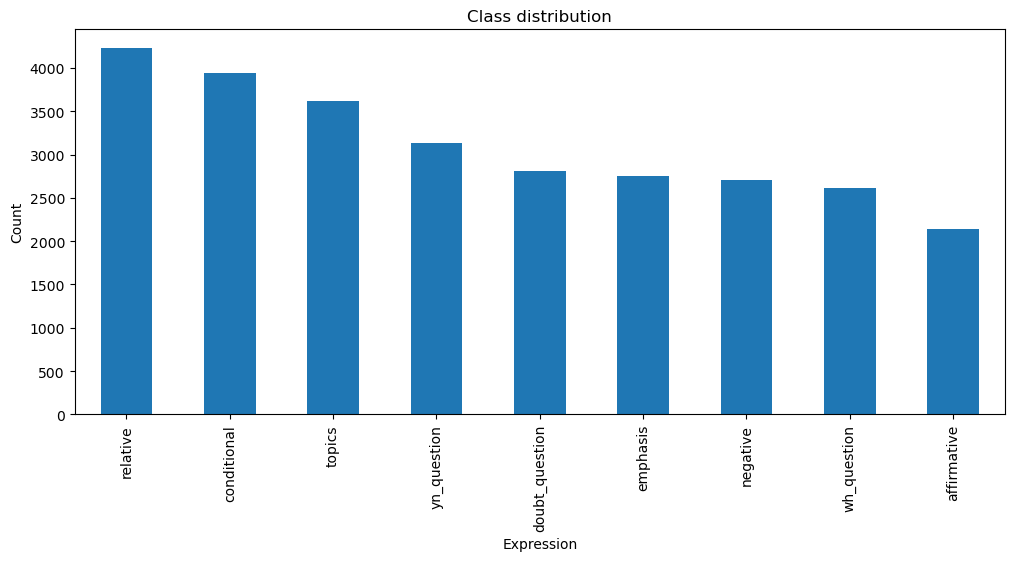

In [24]:
import matplotlib.pyplot as plt

counts = data["expression"].value_counts()
plt.figure(figsize=(12, 5))
counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Expression")
plt.ylabel("Count")
plt.show()

In [25]:
counts = data["expression"].value_counts()

ratio = counts.max() / counts.min()

if ratio < 1.5:
    print("Dataset is balanced")
elif ratio < 3:
    print("Dataset is moderately imbalanced")
else:
    print("Dataset is highly imbalanced")

Dataset is moderately imbalanced
